# Check whether csv images are imported properly

In [1]:
%matplotlib widget
from qcl_analysis.io import load_qcl_csv

In [2]:
file_path = "/Users/ethanjiang/Documents/Cornell/Research/DIY Incubator/Data/A431_04222026_QCL/2026-04-22_021/stacks/pattern0/lineScan_1600_0invcm.csv"

image = load_qcl_csv(file_path)

print("Shape:", image.shape)
print("Min:", image.min())
print("Max:", image.max())
print("Mean:", image.mean())

Shape: (200, 300)
Min: 0.054339154612244395
Max: 6.8610845076374325
Mean: 2.037347584861144


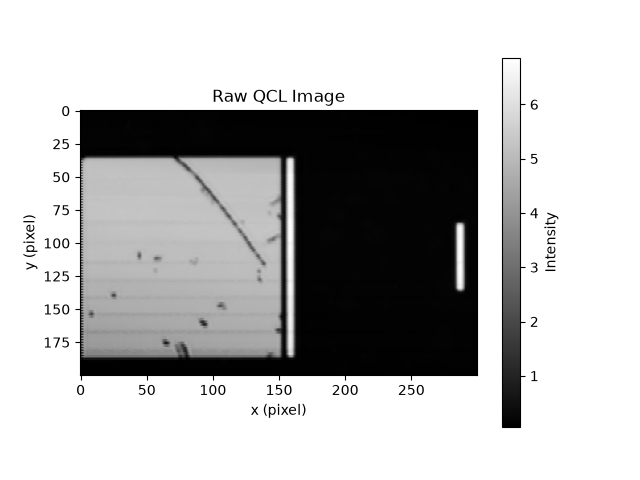

In [3]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")
plt.colorbar(label="Intensity")
plt.title("Raw QCL Image")
plt.xlabel("x (pixel)")
plt.ylabel("y (pixel)")
plt.show()

# Turn data from a given folder into metadata table

In [4]:
from qcl_analysis.metadata import index_qcl_dataset

In [5]:
stacks_path = (
    "/Users/ethanjiang/Documents/Cornell/Research/"
    "DIY Incubator/Data/A431_04222026_QCL/"
    "2026-04-22_021/stacks"
)

dataset = index_qcl_dataset(stacks_path)

dataset

,frame,pattern,wavenumber,path
0,0,pattern0,1600,/Users/ethanjiang/Documents/Cornell/Research/D...
1,0,pattern0,1655,/Users/ethanjiang/Documents/Cornell/Research/D...
2,0,pattern0,1750,/Users/ethanjiang/Documents/Cornell/Research/D...
3,1,pattern1,1600,/Users/ethanjiang/Documents/Cornell/Research/D...
4,1,pattern1,1655,/Users/ethanjiang/Documents/Cornell/Research/D...
...,...,...,...,...
516,173,pattern173,1600,/Users/ethanjiang/Documents/Cornell/Research/D...
517,173,pattern173,1655,/Users/ethanjiang/Documents/Cornell/Research/D...
518,173,pattern173,1750,/Users/ethanjiang/Documents/Cornell/Research/D...
519,174,pattern174,1600,/Users/ethanjiang/Documents/Cornell/Research/D...


In [6]:
dataset.shape

(521, 4)

In [7]:
dataset["frame"].unique()

array([  0,   1,   2,   3,   4,   5,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174])

In [8]:
dataset["wavenumber"].unique()

array([1600, 1655, 1750])

# Check quality of the dataset

In [9]:
from qcl_analysis.qc import validate_dataset_index
from qcl_analysis.qc import find_incomplete_frames
from qcl_analysis.qc import validate_image_files

In [10]:
incomplete = find_incomplete_frames(
    dataset,
    expected_wavenumbers={1600, 1655, 1750},
)

incomplete

{174: [1750]}

In [11]:
image_shape = validate_image_files(dataset)

image_shape

(200, 300)

# Choose points in raw images to be gold reference and calculate reflectance

In [12]:
%matplotlib widget

from qcl_analysis.visualization import (
    BrightestPixelsViewer,
    plot_gold_reference_trend,
)

viewer = BrightestPixelsViewer(
    dataset,
    patterns=[
        "pattern5",
        "pattern100",
    ],
    expected_wavenumbers={
        1600,
        1655,
        1750,
    },
    n_pixels=100,
)

In [13]:
from qcl_analysis.reflectance import (
    add_gold_reference_signals,
    load_reflectance_image,
)

reflectance_dataset = add_gold_reference_signals(
    dataset,
    n_pixels=100,
)

reflectance_dataset[
    [
        "frame",
        "pattern",
        "wavenumber",
        "i_goldref",
    ]
].head(10)

,frame,pattern,wavenumber,i_goldref
0,0,pattern0,1600,6.782312
1,0,pattern0,1655,4.683966
2,0,pattern0,1750,8.570483
3,1,pattern1,1600,6.794790
4,1,pattern1,1655,4.703976
5,1,pattern1,1750,10.609916
6,2,pattern2,1600,6.604422
7,2,pattern2,1655,4.712170
8,2,pattern2,1750,11.241329
9,3,pattern3,1600,6.794879


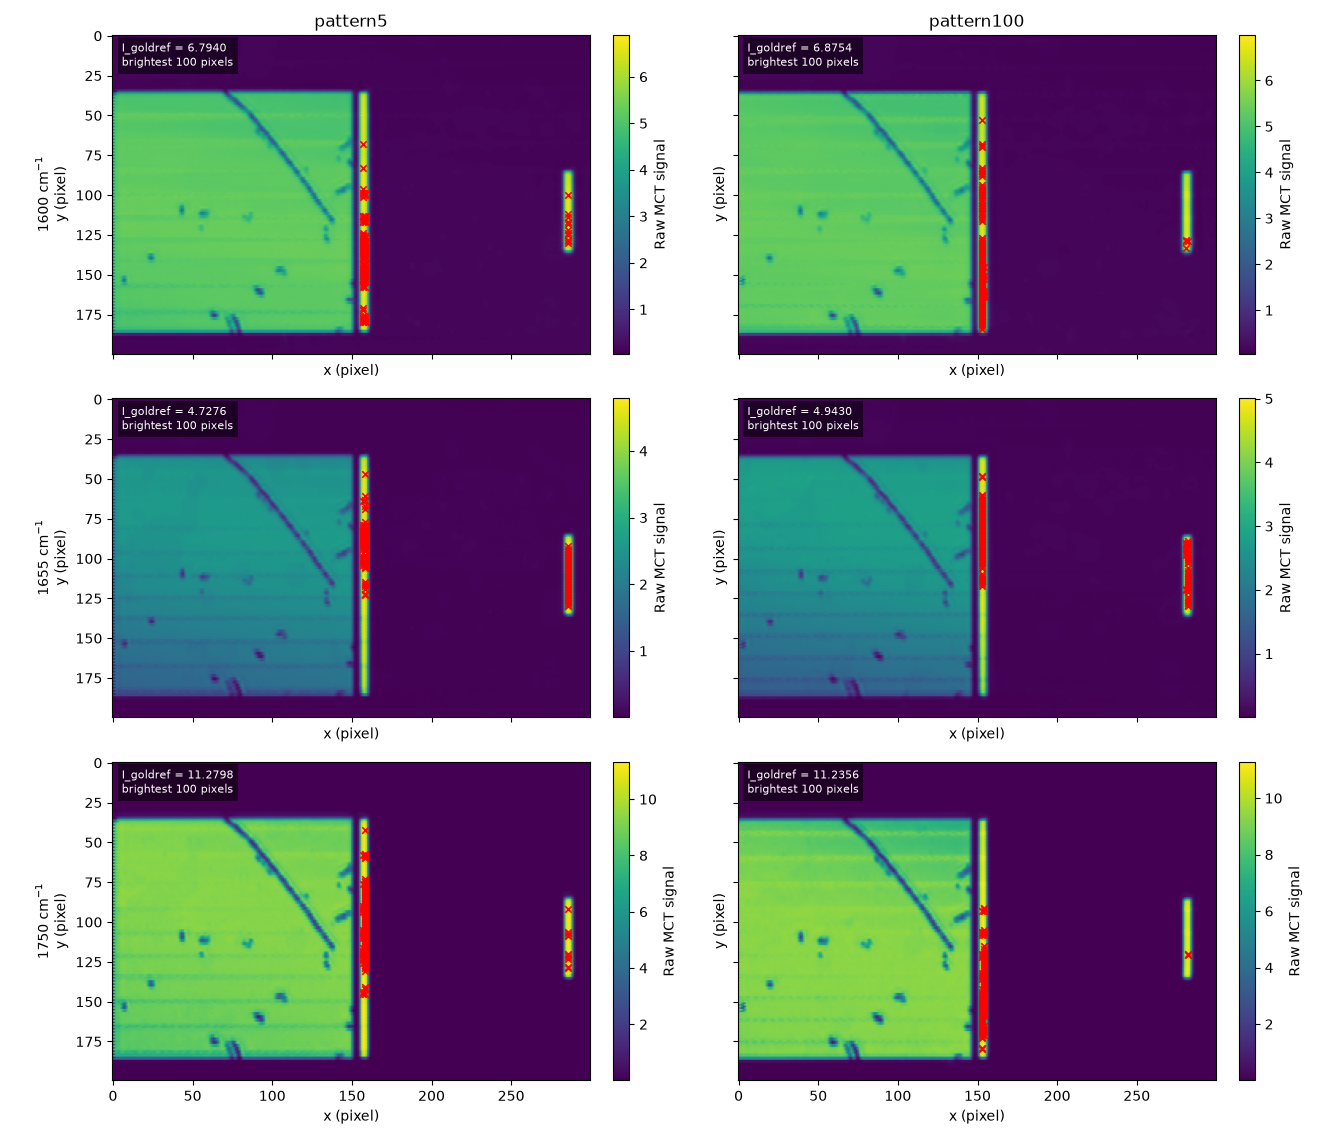

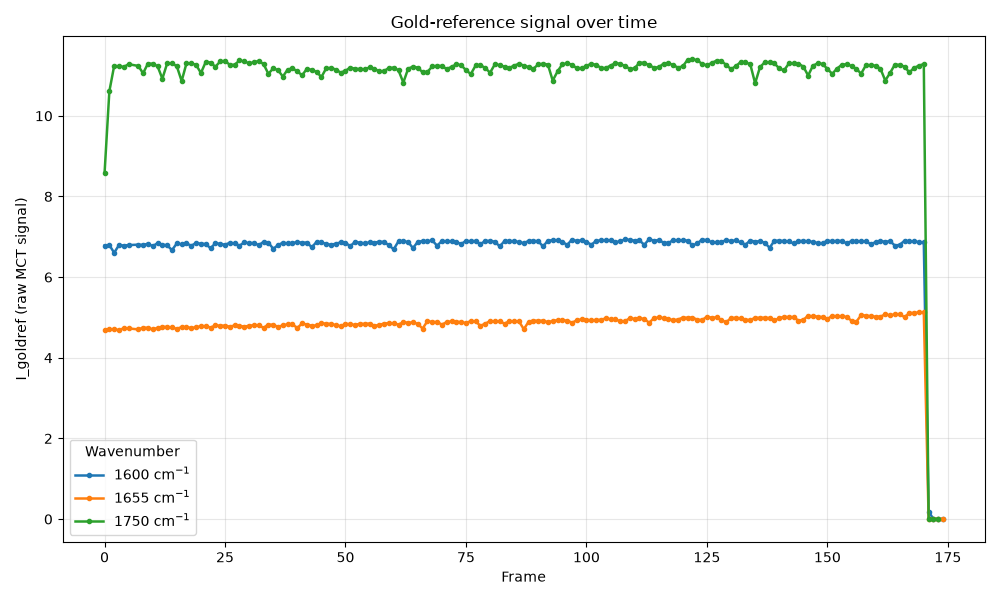

In [14]:
viewer.show()

fig, ax = plot_gold_reference_trend(
    reflectance_dataset
)

plt.show()

# Raw signal gold reference quality control

In [15]:
from qcl_analysis.qc import (
    add_frame_quality_flags,
    add_reference_quality_flags,
)

qc_dataset = add_reference_quality_flags(
    reflectance_dataset,
    robust_z_threshold=5.0,
    min_relative_deviation=0.10,
)

qc_dataset = add_frame_quality_flags(
    qc_dataset,
    expected_wavenumbers={
        1600,
        1655,
        1750,
    },
)

qc_dataset.loc[
    ~qc_dataset["reference_valid"],
    [
        "frame",
        "pattern",
        "wavenumber",
        "i_goldref",
        "reference_median",
        "reference_relative_deviation",
        "reference_robust_z",
        "quality_reason",
    ],
]

,frame,pattern,wavenumber,i_goldref,reference_median,reference_relative_deviation,reference_robust_z,quality_reason
2,0,pattern0,1750,8.570483,11.227101,0.236626,-29.723032,low_reference
510,171,pattern171,1600,0.183500,6.866285,0.973275,-143.344046,low_reference
511,171,pattern171,1655,0.003175,4.898911,0.999352,-38.811986,low_reference
512,171,pattern171,1750,0.003077,11.227101,0.999726,-125.577680,low_reference
513,172,pattern172,1600,0.003155,6.866285,0.999540,-147.212397,low_reference
514,172,pattern172,1655,0.003179,4.898911,0.999351,-38.811956,low_reference
515,172,pattern172,1750,0.003159,11.227101,0.999719,-125.576762,low_reference
516,173,pattern173,1600,0.003083,6.866285,0.999551,-147.213956,low_reference
517,173,pattern173,1655,0.003174,4.898911,0.999352,-38.811995,low_reference
518,173,pattern173,1750,0.003201,11.227101,0.999715,-125.576297,low_reference


In [16]:
bad_frames = sorted(
    qc_dataset.loc[
        ~qc_dataset["frame_valid"],
        "frame",
    ].unique()
)

bad_frames

[np.int64(0), np.int64(171), np.int64(172), np.int64(173), np.int64(174)]

In [17]:
qc_dataset.loc[
    ~qc_dataset["frame_valid"],
    [
        "frame",
        "frame_quality_reason",
    ],
].drop_duplicates()

,frame,frame_quality_reason
0,0,reference_outlier
510,171,reference_outlier
513,172,reference_outlier
516,173,reference_outlier
519,174,reference_outlier;missing_wavenumber:1750


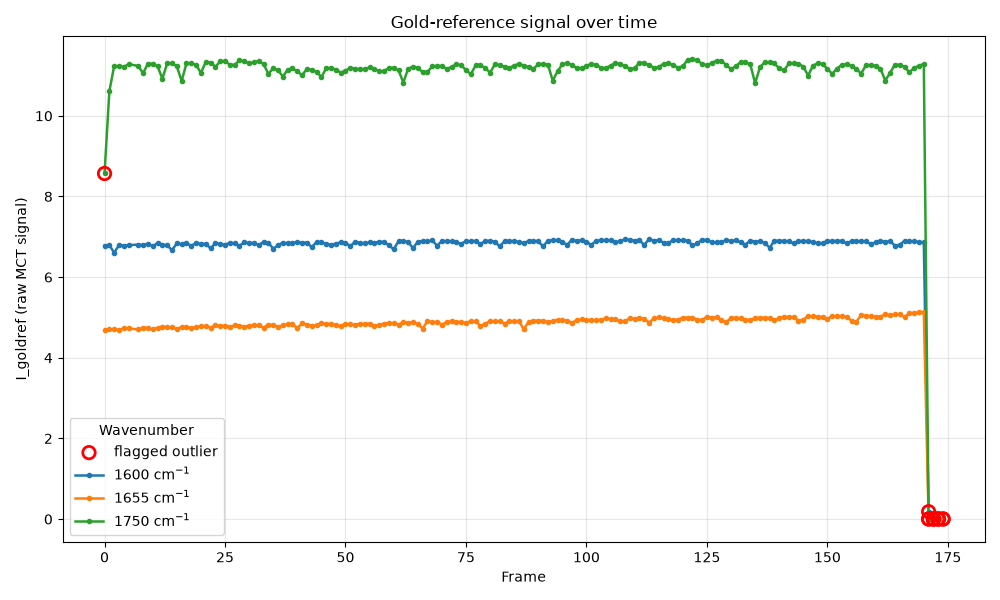

In [18]:
fig, ax = plot_gold_reference_trend(qc_dataset)
plt.show()

In [19]:
qc_dataset.head(20)

,frame,pattern,wavenumber,path,i_goldref,gold_reference_n_pixels,reference_median,reference_mad,reference_relative_deviation,reference_robust_z,reference_valid,quality_reason,frame_valid,frame_quality_reason
0,0,pattern0,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.782312,100,6.866285,0.031445,0.012230,-1.801195,True,good,False,reference_outlier
1,0,pattern0,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.683966,100,4.898911,0.085080,0.043876,-1.704017,True,good,False,reference_outlier
2,0,pattern0,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,8.570483,100,11.227101,0.060285,0.236626,-29.723032,False,low_reference,False,reference_outlier
3,1,pattern1,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.794790,100,6.866285,0.031445,0.010412,-1.533551,True,good,True,good
4,1,pattern1,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.703976,100,4.898911,0.085080,0.039791,-1.545384,True,good,True,good
5,1,pattern1,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,10.609916,100,11.227101,0.060285,0.054973,-6.905258,True,good,True,good
6,2,pattern2,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.604422,100,6.866285,0.031445,0.038137,-5.616889,True,good,True,good
7,2,pattern2,1655,/Users/ethanjiang/Documents/Cornell/Research/D...,4.712170,100,4.898911,0.085080,0.038119,-1.480423,True,good,True,good
8,2,pattern2,1750,/Users/ethanjiang/Documents/Cornell/Research/D...,11.241329,100,11.227101,0.060285,0.001267,0.159178,True,good,True,good
9,3,pattern3,1600,/Users/ethanjiang/Documents/Cornell/Research/D...,6.794879,100,6.866285,0.031445,0.010400,-1.531649,True,good,True,good


# Find cell free region in reflectance images

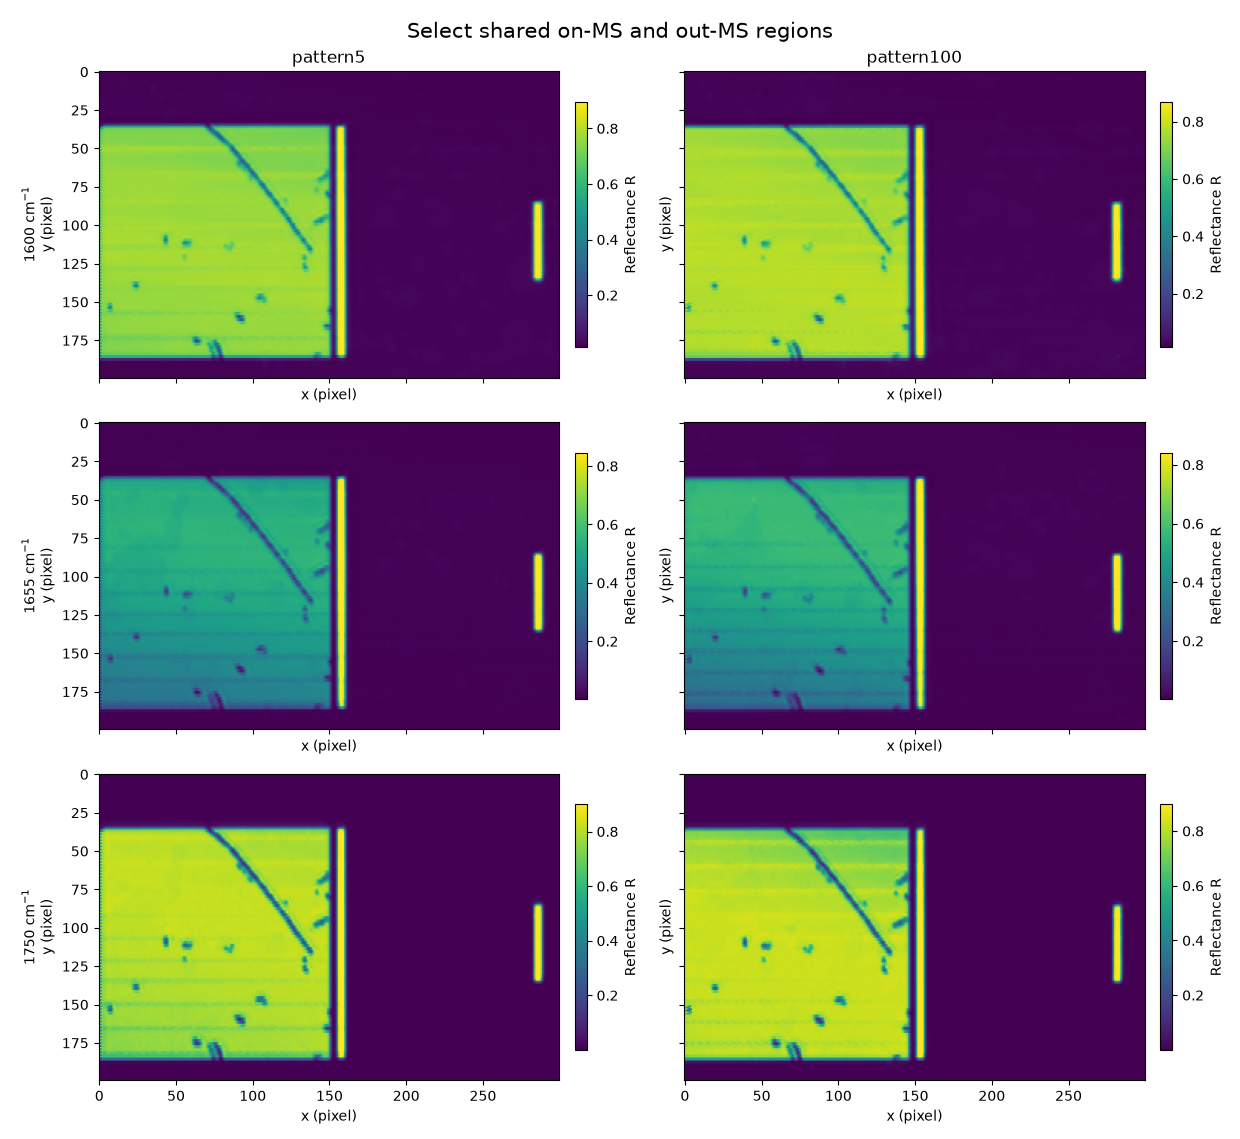

In [20]:
from qcl_analysis.visualization import MSRegionSelector

region_selector = MSRegionSelector(
    qc_dataset,
    patterns=[
        "pattern5",
        "pattern100",
    ],
    expected_wavenumbers={
        1600,
        1655,
        1750,
    },
)

region_selector.show()

# Crop reflectance images to defind regions on and outside of MS

In [23]:
from qcl_analysis.cropping import crop_ms_regions

# Get the confirmed on-MS and out-MS regions
regions = region_selector.get_regions()

on_ms_roi = regions["onMS"]
out_ms_roi = regions["outMS"]

# Get one reflectance image for testing
R = region_selector.get_reflectance_image(
    "pattern5",
    1655,
)

# Crop the reflectance image
R_onMS, R_outMS = crop_ms_regions(
    R,
    on_ms_roi,
    out_ms_roi,
)

print("Original:", R.shape)
print("onMS:", R_onMS.shape)
print("outMS:", R_outMS.shape)

print()
print("onMS ROI:", on_ms_roi)
print("outMS ROI:", out_ms_roi)

Original: (200, 300)
onMS: (148, 145)
outMS: (191, 107)

onMS ROI: ROI(x_min=2, x_max=147, y_min=36, y_max=184)
outMS ROI: ROI(x_min=168, x_max=275, y_min=3, y_max=194)


# Calculate absorbance

In [ ]:
from qcl_analysis.absorbance import calculate_absorbance
from qcl_analysis.reflectance import load_reflectance_image

absorbance_images = {}

for _, r0_row in r0_summary.iterrows():
    pattern = r0_row["pattern"]
    wavenumber = int(r0_row["wavenumber"])
    r0 = float(r0_row["r0"])

    rows = qc_dataset[
        (qc_dataset["pattern"] == pattern)
        & (qc_dataset["wavenumber"] == wavenumber)
    ]

    if rows.empty:
        raise ValueError(
            f"No image found for {pattern}, {wavenumber} cm^-1."
        )

    reflectance = load_reflectance_image(rows.iloc[0])

    absorbance = calculate_absorbance(
        reflectance,
        r0,
    )

    absorbance_images[
        (pattern, wavenumber)
    ] = absorbance

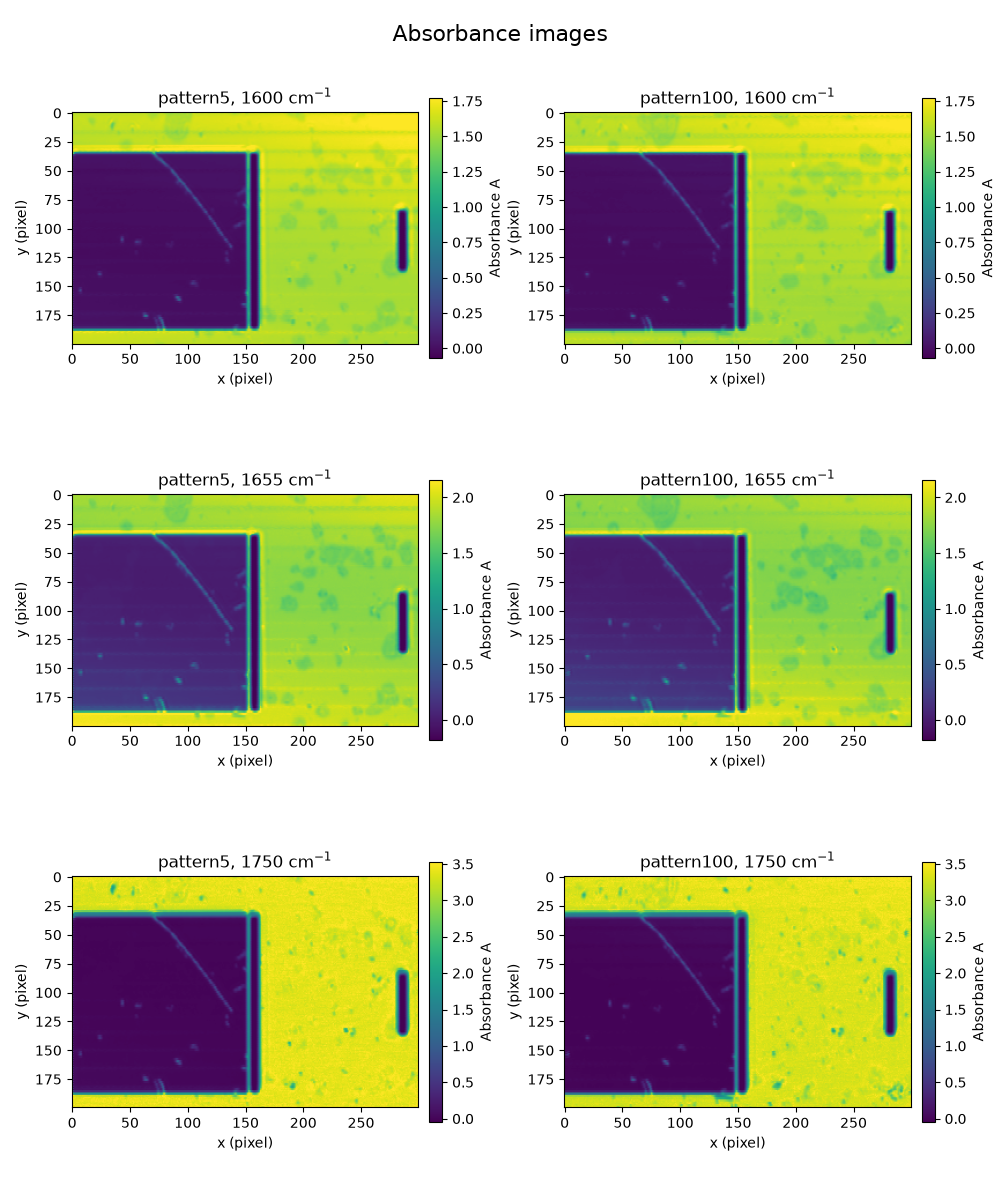

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

patterns = r0_selector.patterns
wavenumbers = r0_selector.wavenumbers

n_rows = len(wavenumbers)
n_cols = len(patterns)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5.0 * n_cols, 4.0 * n_rows),
    squeeze=False,
)

for row_idx, wn in enumerate(wavenumbers):

    # Use the same display range for the same wavenumber
    # across different patterns.
    combined = np.concatenate(
        [
            absorbance_images[(pattern, wn)][
                np.isfinite(absorbance_images[(pattern, wn)])
            ]
            for pattern in patterns
        ]
    )

    vmin, vmax = np.percentile(
        combined,
        [1, 99],
    )

    for col_idx, pattern in enumerate(patterns):
        ax = axes[row_idx, col_idx]

        absorbance = absorbance_images[
            (pattern, wn)
        ]

        im = ax.imshow(
            absorbance,
            origin="upper",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(
            f"{pattern}, {wn} cm$^{{-1}}$"
        )

        ax.set_xlabel("x (pixel)")
        ax.set_ylabel("y (pixel)")

        fig.colorbar(
            im,
            ax=ax,
            label="Absorbance A",
            fraction=0.035,
            pad=0.03,
            shrink=0.8,
        )

fig.suptitle(
    "Absorbance images",
    fontsize=16,
)

fig.tight_layout()
plt.show()